In [6]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)


In [8]:
ds = pd.read_csv(r"E:\random proj\lehrire\creditcard.csv")
print(ds.shape)

(284807, 31)


In [9]:
columns=[]
print("name and type columns :")
for i in range(len(ds.columns)):

    columns.append(ds.columns[i])
print(ds.dtypes)

name and type columns :
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [10]:
head = pd.DataFrame(ds.head())
display(head)
tail = pd.DataFrame(ds.tail())
display(tail)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [11]:
ds.isna().sum().add((ds == '').sum()).add((ds == '?').sum()).add((ds == 'Unknown').sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [12]:
ds = ds.drop_duplicates()
ds.duplicated().sum()

np.int64(0)

,count
Class,
0,283253
1,473


<Axes: xlabel='Class'>

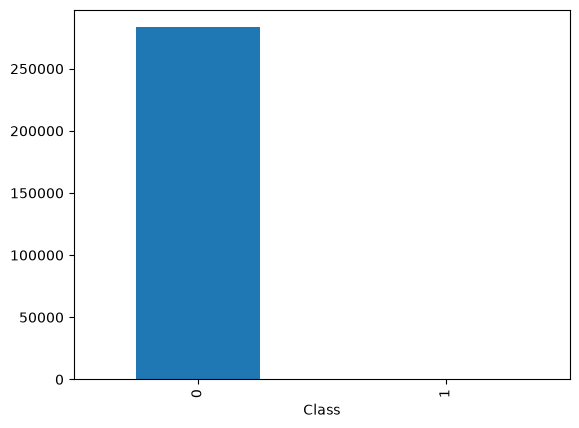

In [13]:
display(pd.DataFrame(ds['Class'].value_counts()))
ds['Class'].value_counts().plot(kind='bar')


count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64


<Axes: ylabel='Frequency'>

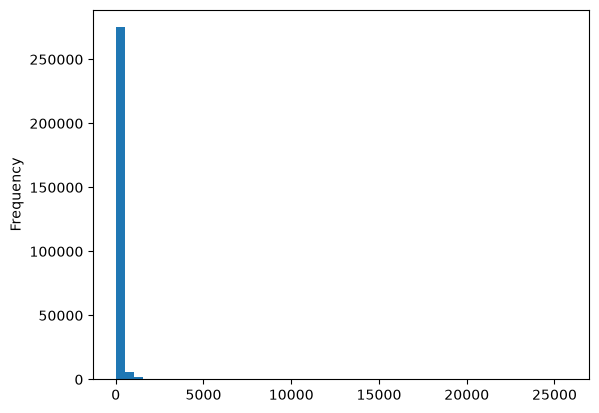

In [14]:
print(ds['Amount'].describe())
ds['Amount'].plot(kind='hist', bins=50)

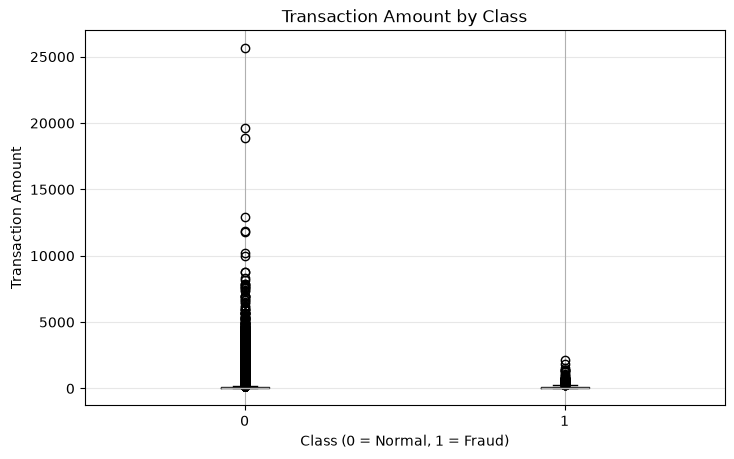

In [15]:
ds.boxplot(column='Amount', by='Class', figsize=(8, 5))

plt.title('Transaction Amount by Class')
plt.suptitle('')
plt.xlabel('Class (0 = Normal, 1 = Fraud)')
plt.ylabel('Transaction Amount')
plt.grid(axis='y', alpha=0.3)

plt.show()

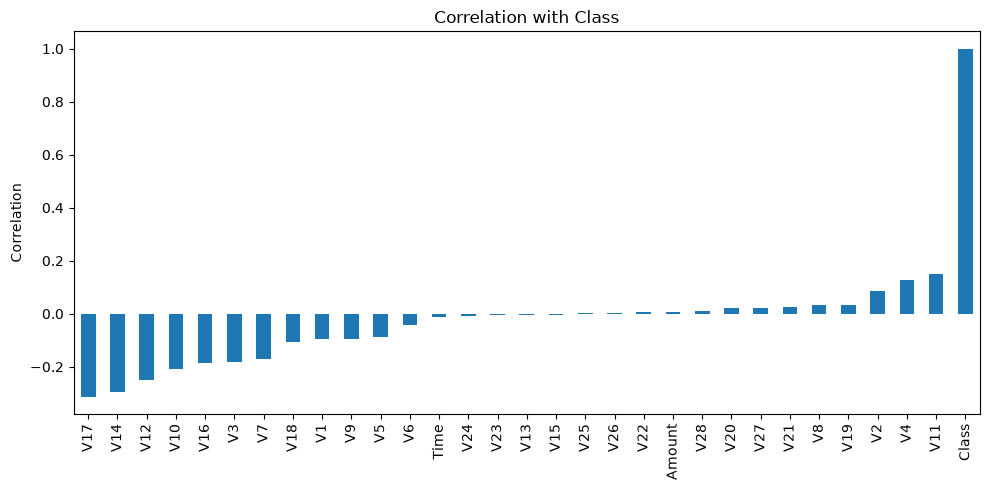

In [16]:
ds.corr(numeric_only=True)['Class'].sort_values().plot(
    kind='bar',
    figsize=(10, 5),
    title='Correlation with Class'
)

plt.ylabel('Correlation')
plt.tight_layout()
plt.show()

In [17]:
Q1 = ds['Amount'].quantile(0.25)
Q3 = ds['Amount'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ds[(ds['Amount'] < lower) | (ds['Amount'] > upper)]

len(outliers)

31685

In [18]:
ds.select_dtypes(include='object').columns

Index([], dtype='str')

In [19]:
X = ds.drop('Class', axis=1)
y = ds['Class']

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,
    random_state=42,
    stratify=y_temp
)

16.978803370060476


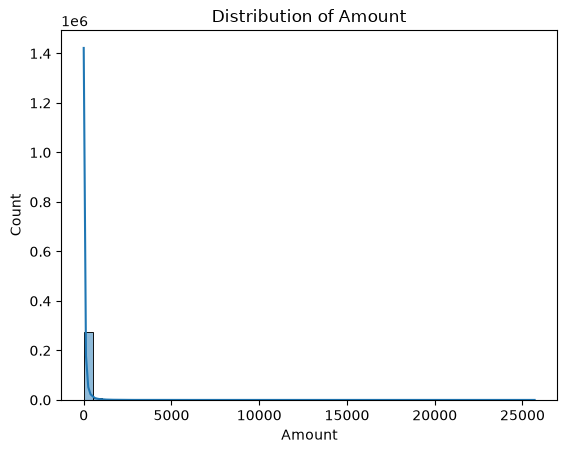

In [21]:
print(ds['Amount'].skew())
sns.histplot(ds['Amount'], bins=50, kde=True)
plt.title('Distribution of Amount')
plt.show()

In [22]:
ds['Amount_log'] = np.log1p(ds['Amount'])
ds['Amount_log'].skew()

np.float64(0.16141018223366635)

V17           0.313498
V14           0.293375
V12           0.250711
V10           0.206971
V16           0.187186
V3            0.182322
V7            0.172347
V11           0.149067
V4            0.129326
V18           0.105340
V1            0.094486
V9            0.094021
V5            0.087812
V2            0.084624
V6            0.043915
V19           0.033631
V8            0.033068
V21           0.026357
V27           0.021892
V20           0.021486
Time          0.012359
V28           0.009682
Amount_log    0.007798
V24           0.007210
V23           0.006333
Amount        0.005777
V22           0.004887
V26           0.004265
V13           0.003897
V15           0.003300
V25           0.003202
Name: Class, dtype: float64


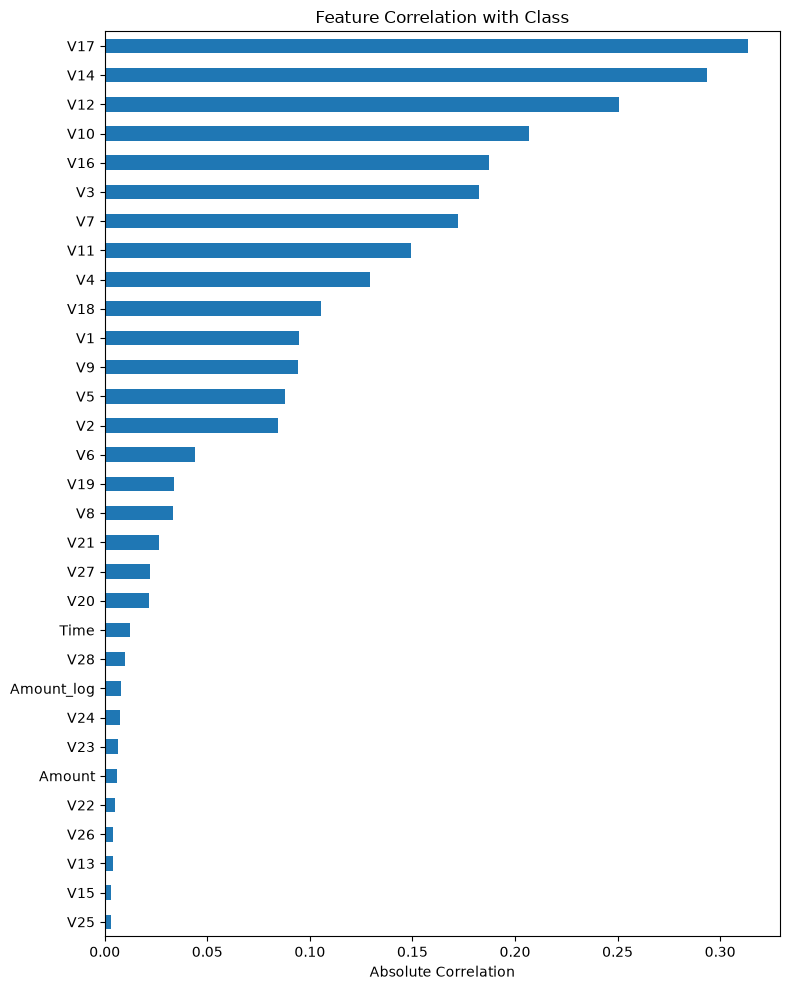

In [23]:
corr = ds.corr(numeric_only=True)['Class'].drop('Class')

print(corr.abs().sort_values(ascending=False))

corr.abs().sort_values().plot(
    kind='barh',
    figsize=(8, 10),
    title='Feature Correlation with Class'
)

plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()

In [ ]:
for k in [10, 15, 20]:
    selector = SelectKBest(
        score_func=mutual_info_classif,
        k=k
    )

    X_train_selected = selector.fit_transform(X_train, y_train)
    selected_features = X_train.columns[selector.get_support()]

    print(f"\nk = {k}")
    print(selected_features)



selector = SelectKBest(
    score_func=mutual_info_classif,
    k=10
)

X_train_selected = selector.fit_transform(X_train, y_train)
X_val_selected = selector.transform(X_val)
X_test_selected = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support()]

print("Selected features:")
print(selected_features)    


k = 10
Index(['V3', 'V4', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18'], dtype='str')

k = 15
Index(['V2', 'V3', 'V4', 'V6', 'V7', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16',
       'V17', 'V18', 'V21', 'V27'],
      dtype='str')

k = 20
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V21', 'V27', 'V28'],
      dtype='str')


In [25]:
print(ds['Time'].describe())
print(ds['Time'].head(20))
print(ds['Time'].nunique())

count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64
0      0.0
1      0.0
2      1.0
3      1.0
4      2.0
5      2.0
6      4.0
7      7.0
8      7.0
9      9.0
10    10.0
11    10.0
12    10.0
13    11.0
14    12.0
15    12.0
16    12.0
17    13.0
18    14.0
19    15.0
Name: Time, dtype: float64
124592


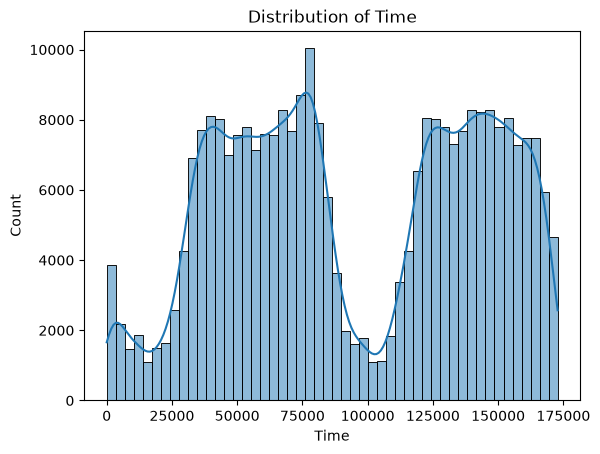

In [26]:
sns.histplot(ds['Time'], bins=50, kde=True)

plt.title('Distribution of Time')
plt.xlabel('Time')
plt.show()

In [27]:
print(ds['Time'].min())
print(ds['Time'].max())

print('\nTransactions around 24 hours:')
print(ds[(ds['Time'] >= 86000) & (ds['Time'] <= 86800)]['Time'].head(20))
print(ds['Time'].max() / 86400)

0.0
172792.0

Transactions around 24 hours:
144284    86001.0
144285    86001.0
144286    86001.0
144287    86003.0
144288    86004.0
144289    86005.0
144290    86006.0
144291    86006.0
144292    86007.0
144293    86007.0
144294    86008.0
144295    86010.0
144296    86010.0
144297    86011.0
144298    86011.0
144299    86012.0
144300    86013.0
144301    86013.0
144302    86015.0
144303    86016.0
Name: Time, dtype: float64
1.9999074074074075


In [28]:
ds['Hour'] = ((ds['Time'] % 86400) // 3600).astype(int)
ds['Day'] = (ds['Time'] // 86400).astype(int)

In [29]:
print(ds.groupby('Day')['Class'].mean())
print(ds.groupby('Hour')['Class'].mean())

Day
0    0.001886
1    0.001441
Name: Class, dtype: float64
Hour
0     0.000785
1     0.002376
2     0.014510
3     0.004875
4     0.010436
5     0.003681
6     0.002205
7     0.003180
8     0.000880
9     0.001015
10    0.000483
11    0.003158
12    0.001105
13    0.001109
14    0.001392
15    0.001588
16    0.001342
17    0.001736
18    0.001651
19    0.001221
20    0.001078
21    0.000908
22    0.000585
23    0.001562
Name: Class, dtype: float64


In [30]:
print(ds.groupby('Hour')['Class'].agg(['count', 'sum', 'mean']).sort_values('mean', ascending=False))

      count  sum      mean
Hour                      
2      3308   48  0.014510
4      2204   23  0.010436
3      3487   17  0.004875
5      2988   11  0.003681
7      7233   23  0.003180
11    16781   53  0.003158
1      4208   10  0.002376
6      4082    9  0.002205
17    16130   28  0.001736
18    16959   28  0.001651
15    16374   26  0.001588
23    10883   17  0.001562
14    16520   23  0.001392
16    16396   22  0.001342
19    15566   19  0.001221
13    15323   17  0.001109
12    15378   17  0.001105
20    16705   18  0.001078
9     15767   16  0.001015
21    17629   16  0.000908
8     10232    9  0.000880
0      7647    6  0.000785
22    15378    9  0.000585
10    16548    8  0.000483


In [ ]:
model = LGBMClassifier(
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 378, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037681 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 226980, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,class_weight,'balanced'
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,min_split_gain,0.0
,min_child_weight,0.001


In [ ]:
y_val_prob = model.predict_proba(X_val)[:, 1]

In [ ]:
thresholds = np.arange(0.1, 1.0, 0.01)

best_threshold = 0
best_f1 = 0
best_precision = 0
best_recall = 0

for threshold in thresholds:
    pred = (y_val_prob >= threshold).astype(int)

    p = precision_score(y_val, pred)
    r = recall_score(y_val, pred)
    f1 = f1_score(y_val, pred)

    if f1 > best_f1:
        best_threshold = threshold
        best_f1 = f1
        best_precision = p
        best_recall = r

print("Best Threshold:", best_threshold)
print("Validation Precision:", best_precision)
print("Validation Recall:", best_recall)
print("Validation F1-score:", best_f1)

In [ ]:
y_test_prob = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)
print(classification_report(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1-score:", f1_score(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.79      0.82        95

    accuracy                           1.00     56746
   macro avg       0.92      0.89      0.91     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.974877667417029
PR-AUC: 0.8065371089403591


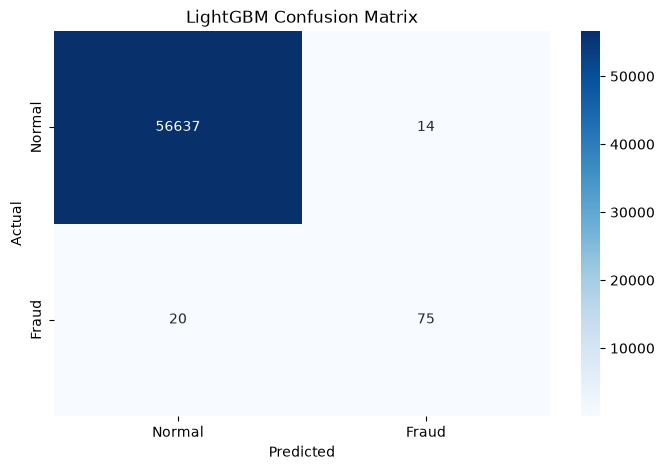

In [ ]:

cm = confusion_matrix(y_test_pred, y_test_pred)

plt.figure(figsize=(8, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LightGBM Confusion Matrix')
plt.show()

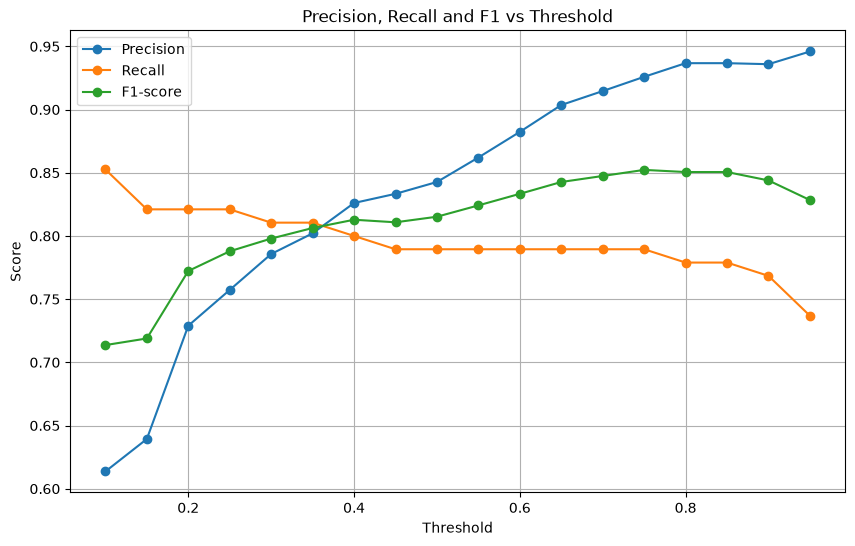

Best Threshold: 0.7500000000000002
Precision: 0.9259259259259259
Recall: 0.7894736842105263
F1-score: 0.8522727272727273


In [47]:
thresholds = np.arange(0.1, 1.0, 0.05)

precision = []
recall = []
f1 = []
results = []


for threshold in thresholds:
    pred = (y_prob >= threshold).astype(int)

    precision.append(precision_score(y_test, pred))
    recall.append(recall_score(y_test, pred))
    f1.append(f1_score(y_test, pred))

    results.append((threshold, precision[-1], recall[-1], f1[-1]))
    
plt.figure(figsize=(10, 6))

plt.plot(thresholds, precision, marker='o', label='Precision')
plt.plot(thresholds, recall, marker='o', label='Recall')
plt.plot(thresholds, f1, marker='o', label='F1-score')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall and F1 vs Threshold')
plt.legend()
plt.grid(True)
plt.show()


best = max(results, key=lambda x: x[3])

print("Best Threshold:", best[0])
print("Precision:", best[1])
print("Recall:", best[2])
print("F1-score:", best[3])